In [46]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.impute import SimpleImputer

from sklearn.linear_model import LinearRegression
from sklearn.svm import SVR
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, BaggingRegressor, GradientBoostingRegressor

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import warnings
warnings.filterwarnings("ignore")

In [47]:
import pandas as pd

df = pd.read_csv("../../data/used_cars.csv.xls")

df.head()

,brand,model,model_year,milage,fuel_type,engine,transmission,ext_col,int_col,accident,clean_title,price
0,Ford,Utility Police Interceptor Base,2013,"51,000 mi.",E85 Flex Fuel,300.0HP 3.7L V6 Cylinder Engine Flex Fuel Capa...,6-Speed A/T,Black,Black,At least 1 accident or damage reported,Yes,"$10,300"
1,Hyundai,Palisade SEL,2021,"34,742 mi.",Gasoline,3.8L V6 24V GDI DOHC,8-Speed Automatic,Moonlight Cloud,Gray,At least 1 accident or damage reported,Yes,"$38,005"
2,Lexus,RX 350 RX 350,2022,"22,372 mi.",Gasoline,3.5 Liter DOHC,Automatic,Blue,Black,None reported,NaN,"$54,598"
3,INFINITI,Q50 Hybrid Sport,2015,"88,900 mi.",Hybrid,354.0HP 3.5L V6 Cylinder Engine Gas/Electric H...,7-Speed A/T,Black,Black,None reported,Yes,"$15,500"
4,Audi,Q3 45 S line Premium Plus,2021,"9,835 mi.",Gasoline,2.0L I4 16V GDI DOHC Turbo,8-Speed Automatic,Glacier White Metallic,Black,None reported,NaN,"$34,999"


In [48]:
import pandas as pd

# Clean price values
df["price"] = (
    df["price"]
    .astype(str)
    .str.replace("$", "", regex=False)
    .str.replace(",", "", regex=False)
    .str.strip()
)

# Convert price to numeric
df["price"] = pd.to_numeric(df["price"], errors="coerce")

print("Price dtype:", df["price"].dtype)
print("Missing prices:", df["price"].isna().sum())
print(df["price"].head())

Price dtype: int64
Missing prices: 0
0    10300
1    38005
2    54598
3    15500
4    34999
Name: price, dtype: int64


In [49]:
# Create price categories
df["price_category"] = pd.qcut(
    df["price"],
    q=3,
    labels=["Low", "Medium", "High"]
)

# Create classification data
X_class = df.drop(["price", "price_category"], axis=1)
y_class = df["price_category"]

print("X_class shape:", X_class.shape)
print(y_class.value_counts())

X_class shape: (4009, 11)
price_category
Low       1339
Medium    1335
High      1335
Name: count, dtype: int64


In [50]:
numerical_features = X_class.select_dtypes(include=["int64", "float64"]).columns.tolist()
categorical_features = X_class.select_dtypes(include=["object", "category"]).columns.tolist()

print("Numerical features:", numerical_features)
print("Categorical features:", categorical_features)

Numerical features: ['model_year']
Categorical features: ['brand', 'model', 'milage', 'fuel_type', 'engine', 'transmission', 'ext_col', 'int_col', 'accident', 'clean_title']


In [51]:
X_train_class, X_test_class, y_train_class, y_test_class = train_test_split(
    X_class,
    y_class,
    test_size=0.2,
    random_state=42,
    stratify=y_class
)

print("Training:", X_train_class.shape)
print("Testing :", X_test_class.shape)

Training: (3207, 11)
Testing : (802, 11)


In [52]:
numeric_transformer_class = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler())
    ]
)

categorical_transformer_class = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("encoder", OneHotEncoder(handle_unknown="ignore"))
    ]
)

preprocessor_class = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer_class, numerical_features),
        ("cat", categorical_transformer_class, categorical_features)
    ]
    )


In [53]:
from sklearn.linear_model import LogisticRegression

logistic_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor_class),
        ("model", LogisticRegression(
            max_iter=1000,
            random_state=42
        ))
    ]
)

logistic_model.fit(X_train_class, y_train_class)

logistic_pred = logistic_model.predict(X_test_class)
logistic_proba = logistic_model.predict_proba(X_test_class)


In [54]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, roc_auc_score

logistic_accuracy = accuracy_score(
    y_test_class,
    logistic_pred
)

logistic_precision = precision_score(
    y_test_class,
    logistic_pred,
    average="weighted"
)

logistic_recall = recall_score(
    y_test_class,
    logistic_pred,
    average="weighted"
)

logistic_auc = roc_auc_score(
    y_test_class,
    logistic_proba,
    multi_class="ovr"
)

print("Accuracy :", round(logistic_accuracy, 4))
print("Precision:", round(logistic_precision, 4))
print("Recall   :", round(logistic_recall, 4))
print("ROC-AUC  :", round(logistic_auc, 4))


Accuracy : 0.8005
Precision: 0.7991
Recall   : 0.8005
ROC-AUC  : 0.9328


In [55]:
from sklearn.neighbors import KNeighborsClassifier

knn_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor_class),
        ("model", KNeighborsClassifier(n_neighbors=5))
    ]
)

knn_model.fit(X_train_class, y_train_class)

knn_pred = knn_model.predict(X_test_class)
knn_proba = knn_model.predict_proba(X_test_class)


In [56]:
knn_accuracy = accuracy_score(y_test_class, knn_pred)

knn_precision = precision_score(
    y_test_class,
    knn_pred,
    average="weighted"
)

knn_recall = recall_score(
    y_test_class,
    knn_pred,
    average="weighted"
)

knn_auc = roc_auc_score(
    y_test_class,
    knn_proba,
    multi_class="ovr"
)

print("Accuracy :", round(knn_accuracy, 4))
print("Precision:", round(knn_precision, 4))
print("Recall   :", round(knn_recall, 4))
print("ROC-AUC  :", round(knn_auc, 4))

Accuracy : 0.7269
Precision: 0.7232
Recall   : 0.7269
ROC-AUC  : 0.8659


In [57]:
from sklearn.svm import SVC

svm_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor_class),
        ("model", SVC(
            kernel="rbf",
            probability=True,
            random_state=42
        ))
    ]
)

svm_model.fit(X_train_class, y_train_class)

svm_pred = svm_model.predict(X_test_class)
svm_proba = svm_model.predict_proba(X_test_class)

In [58]:
svm_accuracy = accuracy_score(y_test_class, svm_pred)

svm_precision = precision_score(
    y_test_class,
    svm_pred,
    average="weighted"
)

svm_recall = recall_score(
    y_test_class,
    svm_pred,
    average="weighted"
)

svm_auc = roc_auc_score(
    y_test_class,
    svm_proba,
    multi_class="ovr"
)

print("Accuracy :", round(svm_accuracy, 4))
print("Precision:", round(svm_precision, 4))
print("Recall   :", round(svm_recall, 4))
print("ROC-AUC  :", round(svm_auc, 4))

Accuracy : 0.7818
Precision: 0.7808
Recall   : 0.7818
ROC-AUC  : 0.9185


In [59]:
from sklearn.naive_bayes import GaussianNB
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler


preprocessor_nb = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numerical_features),
        ("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=False), categorical_features)
    ]
)


nb_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor_nb),
        ("model", GaussianNB())
    ]
)


nb_model.fit(X_train_class, y_train_class)


nb_pred = nb_model.predict(X_test_class)


nb_proba = nb_model.predict_proba(X_test_class)


In [60]:
nb_accuracy = accuracy_score(y_test_class, nb_pred)

nb_precision = precision_score(
    y_test_class,
    nb_pred,
    average="weighted"
)

nb_recall = recall_score(
    y_test_class,
    nb_pred,
    average="weighted"
)

nb_auc = roc_auc_score(
    y_test_class,
    nb_proba,
    multi_class="ovr"
)

print("Accuracy :", round(nb_accuracy, 4))
print("Precision:", round(nb_precision, 4))
print("Recall   :", round(nb_recall, 4))
print("ROC-AUC  :", round(nb_auc, 4))

Accuracy : 0.7307
Precision: 0.7417
Recall   : 0.7307
ROC-AUC  : 0.8363


In [61]:
from sklearn.ensemble import RandomForestClassifier

rf_class_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor_class),
        ("model", RandomForestClassifier(
            n_estimators=200,
            max_depth=20,
            random_state=42,
            n_jobs=-1
        ))
    ]
)

rf_class_model.fit(X_train_class, y_train_class)

rf_class_pred = rf_class_model.predict(X_test_class)
rf_class_proba = rf_class_model.predict_proba(X_test_class)


In [62]:
rf_class_accuracy = accuracy_score(
    y_test_class,
    rf_class_pred
)

rf_class_precision = precision_score(
    y_test_class,
    rf_class_pred,
    average="weighted"
)

rf_class_recall = recall_score(
    y_test_class,
    rf_class_pred,
    average="weighted"
)

rf_class_auc = roc_auc_score(
    y_test_class,
    rf_class_proba,
    multi_class="ovr"
)

print("Accuracy :", round(rf_class_accuracy, 4))
print("Precision:", round(rf_class_precision, 4))
print("Recall   :", round(rf_class_recall, 4))
print("ROC-AUC  :", round(rf_class_auc, 4))

Accuracy : 0.7007
Precision: 0.6974
Recall   : 0.7007
ROC-AUC  : 0.8705


In [63]:
classification_results = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "KNN",
        "SVM",
        "Naive Bayes",
        "Random Forest"
    ],
    "Accuracy": [
        logistic_accuracy,
        knn_accuracy,
        svm_accuracy,
        nb_accuracy,
        rf_class_accuracy
    ],
    "Precision": [
        logistic_precision,
        knn_precision,
        svm_precision,
        nb_precision,
        rf_class_precision
    ],
    "Recall": [
        logistic_recall,
        knn_recall,
        svm_recall,
        nb_recall,
        rf_class_recall
    ],
    "ROC-AUC": [
        logistic_auc,
        knn_auc,
        svm_auc,
        nb_auc,
        rf_class_auc
    ]
})

classification_results.sort_values(
    "ROC-AUC",
    ascending=False
)

,Model,Accuracy,Precision,Recall,ROC-AUC
0,Logistic Regression,0.800499,0.799078,0.800499,0.932753
2,SVM,0.781796,0.780831,0.781796,0.918542
4,Random Forest,0.700748,0.697356,0.700748,0.870469
1,KNN,0.726933,0.723178,0.726933,0.865935
3,Naive Bayes,0.730673,0.741674,0.730673,0.836340


In [64]:
import seaborn as sns
import matplotlib.pyplot as plt

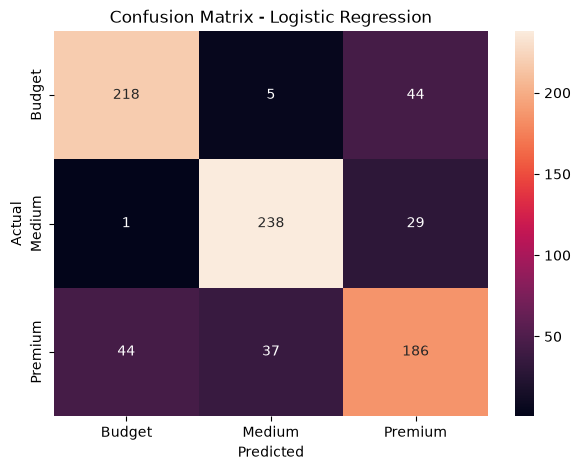

In [65]:
from sklearn.metrics import confusion_matrix

best_class_model_name = classification_results.loc[
    classification_results["ROC-AUC"].idxmax(),
    "Model"
]

predictions = {
    "Logistic Regression": logistic_pred,
    "KNN": knn_pred,
    "SVM": svm_pred,
    "Naive Bayes": nb_pred,
    "Random Forest": rf_class_pred
}

best_class_pred = predictions[best_class_model_name]

cm = confusion_matrix(
    y_test_class,
    best_class_pred
)

plt.figure(figsize=(7, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    xticklabels=["Budget", "Medium", "Premium"],
    yticklabels=["Budget", "Medium", "Premium"]
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title(f"Confusion Matrix - {best_class_model_name}")
plt.show()

In [66]:
from sklearn.metrics import classification_report

print(
    classification_report(
        y_test_class,
        best_class_pred
    )
)

              precision    recall  f1-score   support

        High       0.83      0.82      0.82       267
         Low       0.85      0.89      0.87       268
      Medium       0.72      0.70      0.71       267

    accuracy                           0.80       802
   macro avg       0.80      0.80      0.80       802
weighted avg       0.80      0.80      0.80       802



In [67]:
X = df.drop("price", axis=1)

In [68]:
import pandas as pd
import numpy as np

from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer

X_cluster = X.copy()

numerical_features_cluster = X_cluster.select_dtypes(
    include=np.number
).columns.tolist()

categorical_features_cluster = X_cluster.select_dtypes(
    exclude=np.number
).columns.tolist()

cluster_preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numerical_features_cluster),
        ("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=False), categorical_features_cluster)
    ]
)

X_cluster_scaled = cluster_preprocessor.fit_transform(X_cluster)

print(X_cluster_scaled.shape)

(4009, 6473)


In [69]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)

kmeans_labels = kmeans.fit_predict(X_cluster_scaled)

kmeans_silhouette = silhouette_score(X_cluster_scaled, kmeans_labels)

print("K-Means:", kmeans_silhouette)
print(pd.Series(kmeans_labels).value_counts())

K-Means: 0.06861124947543917
1    1448
2    1287
0    1274
Name: count, dtype: int64


In [70]:
from sklearn.cluster import AgglomerativeClustering

hierarchical = AgglomerativeClustering(n_clusters=3)

hierarchical_labels = hierarchical.fit_predict(X_cluster_scaled)

hierarchical_silhouette = silhouette_score(
    X_cluster_scaled,
    hierarchical_labels
)

print("Hierarchical:", hierarchical_silhouette)
print(pd.Series(hierarchical_labels).value_counts())

Hierarchical: 0.060426092061703365
1    1843
0    1539
2     627
Name: count, dtype: int64


In [71]:
from sklearn.cluster import DBSCAN

dbscan = DBSCAN(eps=0.5, min_samples=5)

dbscan_labels = dbscan.fit_predict(X_cluster_scaled)

print(pd.Series(dbscan_labels).value_counts())

mask = dbscan_labels != -1

if len(set(dbscan_labels[mask])) > 1:
    dbscan_silhouette = silhouette_score(
        X_cluster_scaled[mask],
        dbscan_labels[mask]
    )
    print("DBSCAN:", dbscan_silhouette)

-1    4009
Name: count, dtype: int64


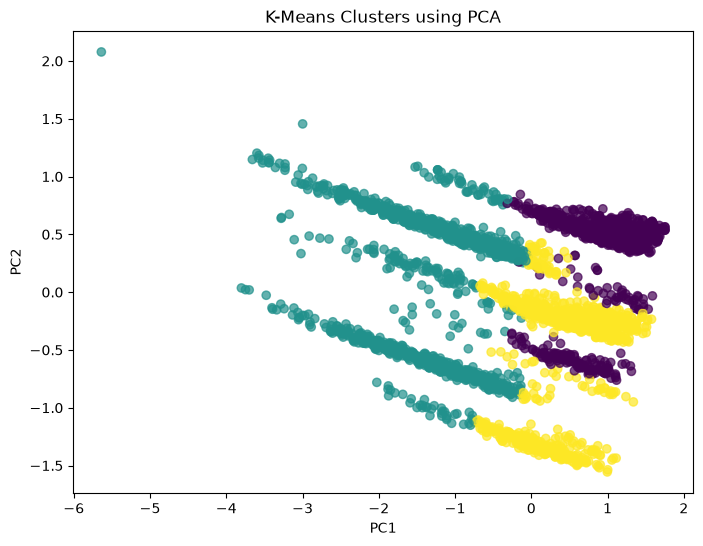

In [72]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

pca = PCA(n_components=2)

X_pca = pca.fit_transform(X_cluster_scaled)

plt.figure(figsize=(8, 6))

plt.scatter(
    X_pca[:, 0],
    X_pca[:, 1],
    c=kmeans_labels,
    alpha=0.7
)

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("K-Means Clusters using PCA")
plt.show()

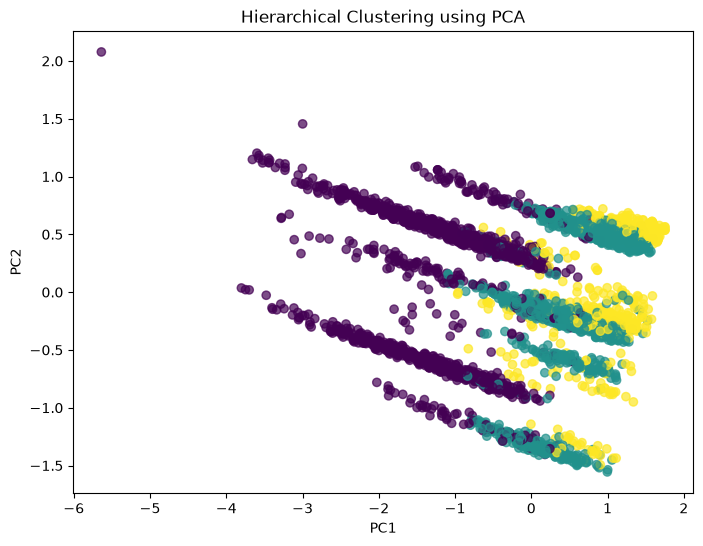

In [73]:
plt.figure(figsize=(8, 6))

plt.scatter(
    X_pca[:, 0],
    X_pca[:, 1],
    c=hierarchical_labels,
    alpha=0.7
)

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("Hierarchical Clustering using PCA")
plt.show()

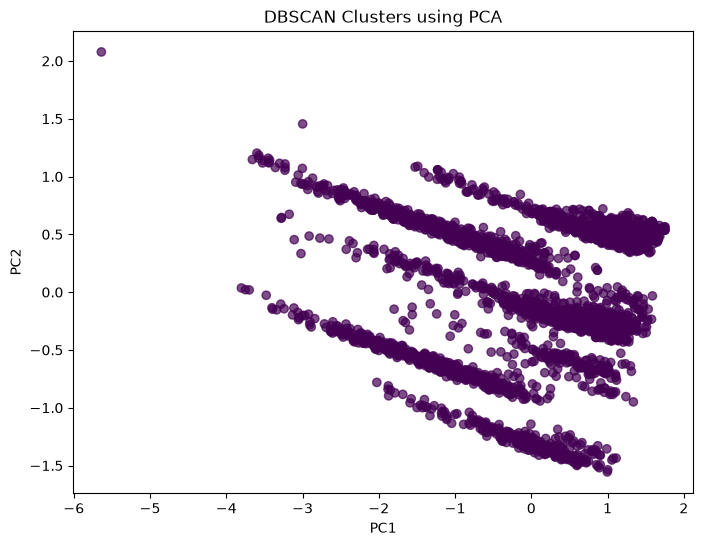

In [74]:
plt.figure(figsize=(8, 6))

plt.scatter(
    X_pca[:, 0],
    X_pca[:, 1],
    c=dbscan_labels,
    alpha=0.7
)

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("DBSCAN Clusters using PCA")
plt.show()

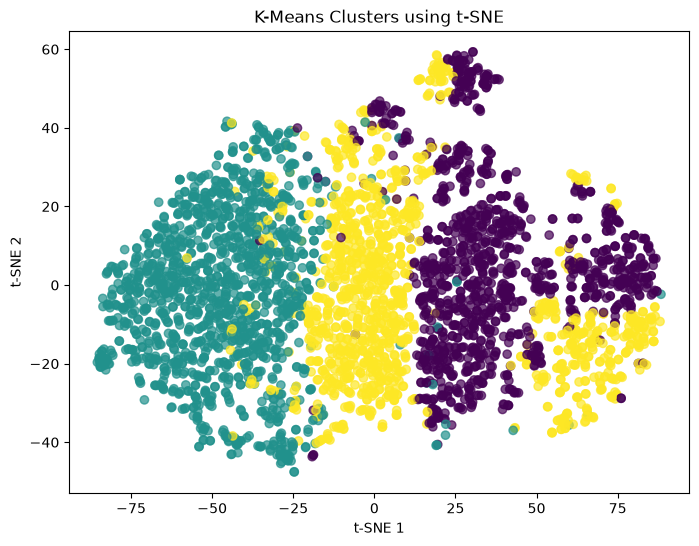

In [75]:
from sklearn.manifold import TSNE

tsne = TSNE(
    n_components=2,
    random_state=42,
    perplexity=30
)

X_tsne = tsne.fit_transform(X_cluster_scaled)

plt.figure(figsize=(8, 6))

plt.scatter(
    X_tsne[:, 0],
    X_tsne[:, 1],
    c=kmeans_labels,
    alpha=0.7
)

plt.xlabel("t-SNE 1")
plt.ylabel("t-SNE 2")
plt.title("K-Means Clusters using t-SNE")
plt.show()

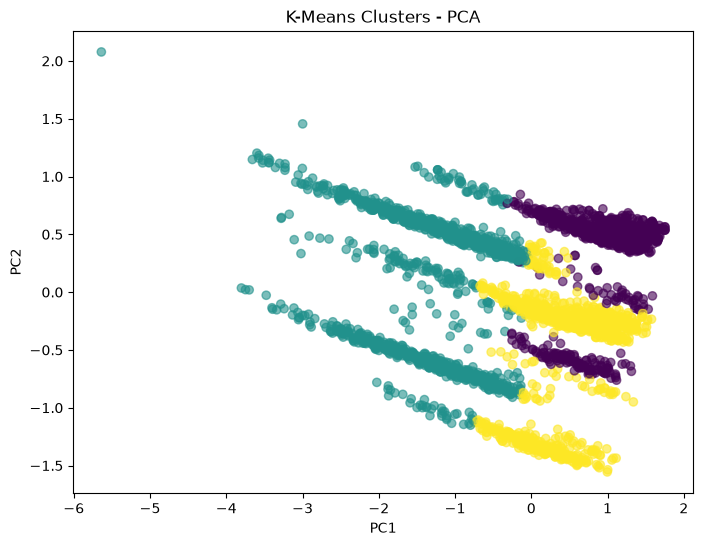

Explained Variance: [0.13899166 0.04077035]


In [76]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

pca = PCA(n_components=2)

X_pca = pca.fit_transform(X_cluster_scaled)

plt.figure(figsize=(8, 6))
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=kmeans_labels, alpha=0.6)

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("K-Means Clusters - PCA")
plt.show()

print("Explained Variance:", pca.explained_variance_ratio_)

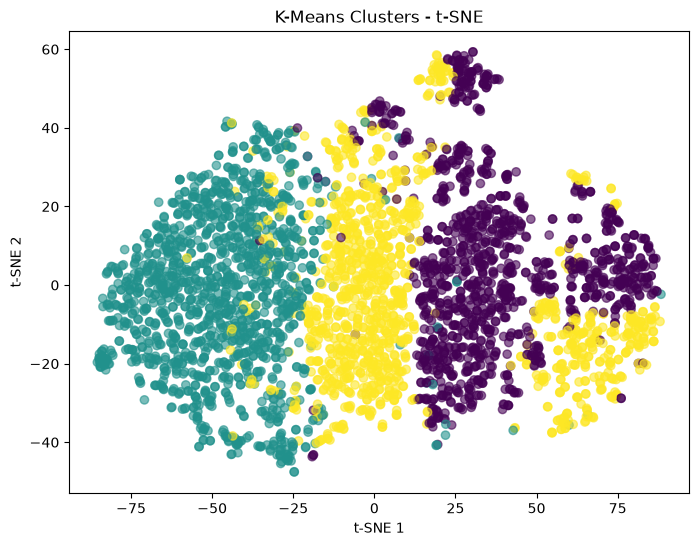

In [77]:
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt

tsne = TSNE(
    n_components=2,
    random_state=42,
    perplexity=30
)

X_tsne = tsne.fit_transform(X_cluster_scaled)

plt.figure(figsize=(8, 6))
plt.scatter(
    X_tsne[:, 0],
    X_tsne[:, 1],
    c=kmeans_labels,
    alpha=0.6
)

plt.xlabel("t-SNE 1")
plt.ylabel("t-SNE 2")
plt.title("K-Means Clusters - t-SNE")
plt.show()

In [78]:
cluster_data = X.copy()
cluster_data["Cluster"] = kmeans_labels

cluster_summary = cluster_data.groupby("Cluster").mean(numeric_only=True)

cluster_summary

,model_year
Cluster,
0,2020.099686
1,2009.272790
2,2018.001554


In [79]:
cluster_summary.T

Cluster,0,1,2
model_year,2020.099686,2009.27279,2018.001554


In [80]:
cluster_data = X.copy()
cluster_data["Cluster"] = kmeans_labels

cluster_summary = cluster_data.groupby("Cluster").mean(numeric_only=True)

print(cluster_summary.T)

Cluster               0           1            2
model_year  2020.099686  2009.27279  2018.001554


In [81]:
y = df["price"]

In [82]:
cluster_data = X.copy()
cluster_data["Cluster"] = kmeans_labels
cluster_data["price"] = y.values

print(cluster_data.groupby("Cluster").mean(numeric_only=True).T)

Cluster                0             1             2
model_year   2020.099686   2009.272790   2018.001554
price       84165.145997  21639.577348  31121.395493


In [83]:
results = pd.DataFrame({
    "Model": [
        "K-Means",
        "Hierarchical"
    ],
    "Silhouette Score": [
        kmeans_silhouette,
        hierarchical_silhouette
    ]
})

results.sort_values("Silhouette Score", ascending=False)

,Model,Silhouette Score
0,K-Means,0.068611
1,Hierarchical,0.060426


In [84]:
import joblib

joblib.dump(kmeans, "kmeans_model.pkl")
joblib.dump(cluster_preprocessor, "cluster_preprocessor.pkl")

['cluster_preprocessor.pkl']

In [85]:
print(X.columns.tolist())


['brand', 'model', 'model_year', 'milage', 'fuel_type', 'engine', 'transmission', 'ext_col', 'int_col', 'accident', 'clean_title', 'price_category']


In [86]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.pipeline import Pipeline
import joblib

price_model = Pipeline([
    ("preprocessor", cluster_preprocessor),
    ("model", RandomForestRegressor(
        n_estimators=200,
        random_state=42,
        n_jobs=-1
    ))
])

price_model.fit(X, y)

joblib.dump(price_model, "price_model.pkl")

['price_model.pkl']

In [87]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

X_train_price, X_test_price, y_train_price, y_test_price = train_test_split(
    X, y, test_size=0.2, random_state=42
)

price_model.fit(X_train_price, y_train_price)

price_pred = price_model.predict(X_test_price)

mae = mean_absolute_error(y_test_price, price_pred)
rmse = np.sqrt(mean_squared_error(y_test_price, price_pred))
r2 = r2_score(y_test_price, price_pred)

print("MAE:", mae)
print("RMSE:", rmse)
print("R2 Score:", r2)

MAE: 17545.439981296757
RMSE: 134366.16818140302
R2 Score: 0.11670029130812687


In [88]:
print(y.describe())

count    4.009000e+03
mean     4.455319e+04
std      7.871064e+04
min      2.000000e+03
25%      1.720000e+04
50%      3.100000e+04
75%      4.999000e+04
max      2.954083e+06
Name: price, dtype: float64


In [89]:
print("Max price:", y.max())
print("Min price:", y.min())

Max price: 2954083
Min price: 2000


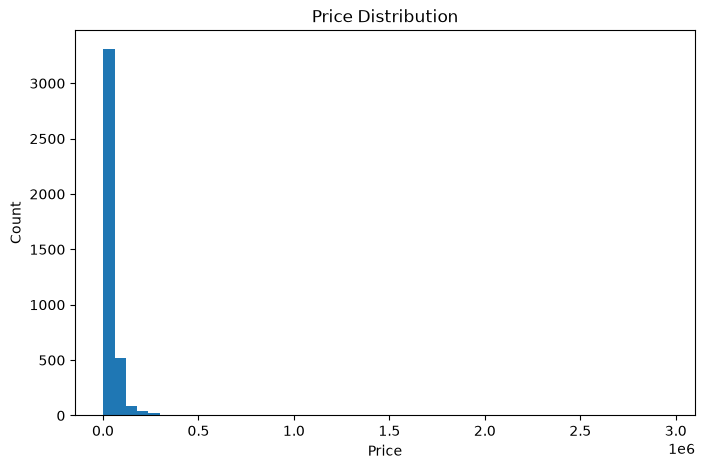

In [90]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
plt.hist(y, bins=50)
plt.xlabel("Price")
plt.ylabel("Count")
plt.title("Price Distribution")
plt.show()